### 9. Churn Threshold Definition

Churn is defined as a business-informed inactivity threshold that:

- reflects true customer attrition  
- aligns with observed customer behavior  

**Goal:** determine the number of days of inactivity after which a customer is unlikely to return.


In [2]:
# ==============================
# 0. Setup
# ==============================

# Loading necessary libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from local_config import *

engine = create_engine(
    f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'
)

orders = pd.read_sql("SELECT * FROM public.orders", engine)

### Step 1. Distribution of Days Between Orders

We first analyze the distribution of time intervals between consecutive purchases to understand general customer behavior.

While this method does not directly define churn, it helps establish baseline expectations and identify typical return windows.

In [3]:
# ==============================
# 1. Prepare data
# ==============================

orders = orders.sort_values(by=['customer_id', 'order_date']).reset_index(drop=True)
orders['next_order_date'] = orders.groupby('customer_id')['order_date'].shift(-1)
orders['days_between_orders'] = pd.to_timedelta(orders['next_order_date'] - orders['order_date']).dt.days.astype('Int64')

In [4]:
# ==============================
# 2. Distribution analysis
# ==============================
# Summary statistics
orders['days_between_orders'].describe()
orders['days_between_orders'].quantile([0.5, 0.75, 0.9])

0.50    14
0.75    41
0.90    88
Name: days_between_orders, dtype: Int64

In [5]:
# Binning based on percentiles
bins = [0, 14, 41, 88, np.inf]
labels = ['0-14', '15-41', '42-88', '88+']

orders['bin'] = pd.cut(orders['days_between_orders'], bins=bins, labels=labels)

orders_hist = (
    orders
    .groupby('bin')['customer_id']
    .nunique()
    .reset_index(name='unique_customers')
)


/var/folders/zy/ggh_5ccd5q74n976swz5d6f80000gn/T/ipykernel_98249/3560955689.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('bin')['customer_id']


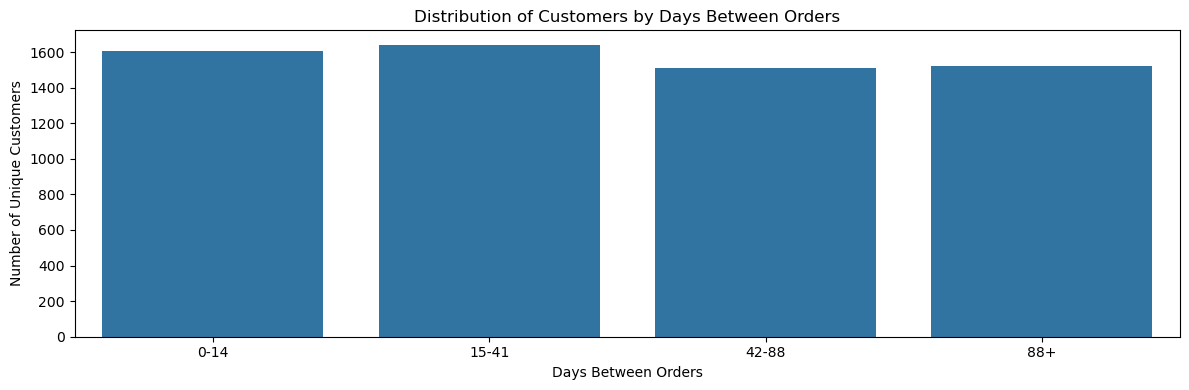

In [6]:
# Visualization
plt.figure(figsize=(12, 4))
sns.barplot(data=orders_hist, x='bin', y='unique_customers')
plt.title('Distribution of Customers by Days Between Orders')
plt.xlabel('Days Between Orders')
plt.ylabel('Number of Unique Customers')
plt.tight_layout()
plt.show()

### Insights

- Median time between purchases: **14 days**  
- 75% of repeat purchases occur within **41 days**  
- 90% occur within **88 days**

This suggests that most customers return within a 3-month period.

However, the distribution does not show a clear drop-off point, indicating that distribution analysis alone is insufficient to define churn.

---

### Step 2. Survival / Return Analysis

To better understand customer behavior, we analyze the cumulative probability of return over time.

Specifically, we calculate the share of customers who return within:

- 30 days (short-term)
- 60 days (mid-term)
- 90 days (expected return window)
- 120 days (long tail)

Note: In this context, "survival" refers to the time until the next purchase. 
A customer is considered to have "survived" up to N days if they have not made a repeat purchase within that period.

In [7]:

df = orders[orders['days_between_orders'].notna()].copy()

thresholds = [30, 60, 90, 120]

results = []
total_intervals = len(df)

for N in thresholds:
    
    survived = (df['days_between_orders'] >= N).sum()
    survival_rate = survived / total_intervals  # survival_rate = % of intervals where the customer has NOT returned yet by day N (i.e., time until next purchase is >= N)   
    return_rate = 1 - survival_rate
    
    results.append({
        'N_days': N,
        'survival_rate': survival_rate,
        'return_rate': return_rate
    })

survival_df = pd.DataFrame(results)


In [8]:
survival_df

,N_days,survival_rate,return_rate
0,30,0.329218,0.670782
1,60,0.166798,0.833202
2,90,0.098664,0.901336
3,120,0.059098,0.940902


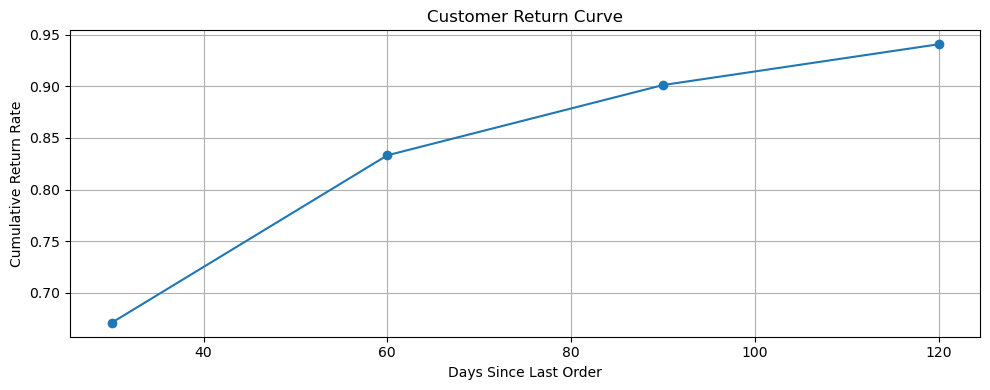

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(survival_df['N_days'], survival_df['return_rate'], marker='o')
plt.xlabel('Days Since Last Order')
plt.ylabel('Cumulative Return Rate')
plt.title('Customer Return Curve')
plt.grid()
plt.tight_layout()
plt.show()

### Key Findings

* **67%** of customers return within 30 days
* **83%** return within 60 days
* **90%** return within 90 days
* Only an additional **4%** return between 90 and 120 days

This shows that:

* The majority of customer returns happen within the first 90 days
* After 90 days, the probability of return significantly diminishes
* The return curve begins to plateau beyond this point

---


### Churn Threshold Definition

> Based on the analysis, a customer is considered **churned** if they have not placed an order within **90 days** since their last purchase.
